In [1]:
import os
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Plot simulation

In [8]:
num_hosts = 16
nodes = 16 # This is the nodes used for greedy local algorithm, 1 if global
processors_per_host = 36
processors = num_hosts * processors_per_host

grouping = "temp/groups_mod16.csv"

test_name = f"greedy/c48_p{processors}"

if nodes > 1:
    test_name += f"_h{nodes}"
    if grouping:
        if grouping.isdigit():
            seed = int(grouping)
            path = None
            test_name += f"_s{seed}"
        else:
            seed = 0
            path = Path(grouping)
            test_name += f"_f{path.stem}"
    else:
        seed = 0
        path = None

test_name

'greedy/c48_p576_h16_fgroups_mod16'

In [9]:
simulation_data_path = f"test/{test_name}/simulation.csv"
simulation_data = pd.read_csv(simulation_data_path, index_col=0)
# Exclude the last four columns and select only numeric columns
simulation_data = simulation_data.iloc[:, :-4].select_dtypes(include=[np.number])
simulation_data

,Processor0,Processor1,Processor2,Processor3,Processor4,Processor5,Processor6,Processor7,Processor8,Processor9,...,Processor566,Processor567,Processor568,Processor569,Processor570,Processor571,Processor572,Processor573,Processor574,Processor575
Interval,,,,,,,,,,,,,,,,,,,,,
0,4571.0,4743.0,4959.0,4342.0,4377.0,6058.0,5670.0,5423.0,4823.0,4905.0,...,5831.0,7787.0,4730.0,4710.0,5287.0,4315.0,4580.0,5575.0,5603.0,5669.0
1,3744.0,3989.0,4139.0,3922.0,4290.0,4417.0,4610.0,4252.0,4195.0,4001.0,...,4480.0,5042.0,4223.0,3980.0,4357.0,3946.0,4222.0,4415.0,4982.0,4519.0
2,3460.0,4042.0,3863.0,3789.0,4164.0,4298.0,4381.0,4081.0,3986.0,3818.0,...,4357.0,5079.0,3952.0,3896.0,3982.0,3811.0,4143.0,4122.0,4599.0,4300.0
3,3431.0,3712.0,3825.0,3837.0,4110.0,4077.0,4410.0,3872.0,3898.0,3874.0,...,4325.0,4700.0,3784.0,3789.0,4915.0,3881.0,4115.0,3949.0,4245.0,4001.0
4,3420.0,3618.0,3796.0,3765.0,4120.0,4187.0,4311.0,3585.0,3882.0,3641.0,...,4233.0,4624.0,3869.0,3779.0,4579.0,3960.0,4080.0,4014.0,4166.0,3920.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,4915.0,4343.0,3840.0,3890.0,3607.0,3926.0,4483.0,5286.0,4795.0,4501.0,...,4705.0,5433.0,6184.0,4859.0,4018.0,3831.0,3370.0,4004.0,4488.0,5087.0
500,4836.0,4149.0,3869.0,3887.0,3645.0,4017.0,4506.0,5218.0,4751.0,4238.0,...,4665.0,5413.0,4942.0,4630.0,4066.0,3714.0,3478.0,4085.0,4447.0,4966.0
501,4675.0,4110.0,3832.0,3859.0,3531.0,3963.0,4693.0,5126.0,4265.0,4051.0,...,5443.0,5380.0,6277.0,4895.0,4158.0,3559.0,3420.0,4056.0,4532.0,5007.0


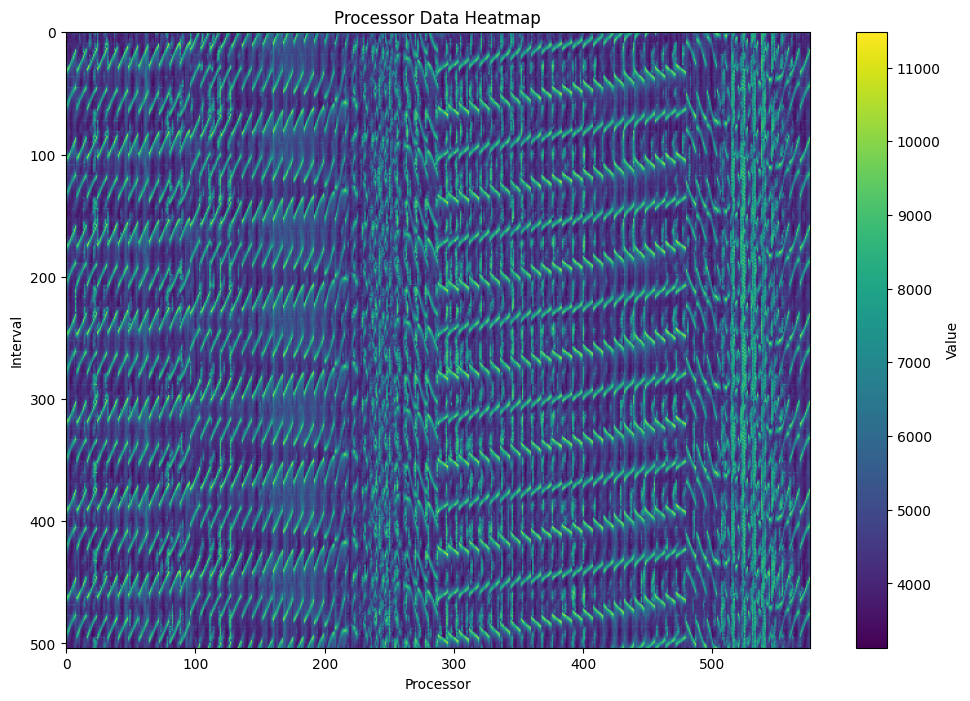

In [10]:
# Plot the simulation data as a heatmap,
def plot_simulation_heatmap(data: pd.DataFrame, heatmap_type: str = "processor", path: Optional[str] = None):
    """
    Plot a heatmap of the simulation data.
    Args:
        data (pd.DataFrame): The data to plot.
        heatmap_type (str): Label for the x-axis (e.g., 'processor', 'node').
        path (Optional[str]): If provided, save the plot to this directory.
    """
    plt.figure(figsize=(12, 8))
    cax = plt.imshow(data, aspect="auto", cmap="viridis")
    plt.colorbar(cax, label="Value")
    plt.xlabel(heatmap_type.capitalize())
    plt.ylabel("Interval")
    plt.title(f"{heatmap_type.capitalize()} Data Heatmap")
    if path:
        os.makedirs(path, exist_ok=True)
        plt.savefig(f"{path}/{heatmap_type}_heatmap.png")
        plt.savefig(f"{path}/{heatmap_type}_heatmap.eps")
    plt.show()

# Plot the simulation data heatmap
plot_simulation_heatmap(
    simulation_data, heatmap_type="processor", path=f"test/plots/{test_name}"
)

Generate random grouping or read from input file

In [11]:
def generate_group_from_seed(
    num_hosts: int, processors_per_host: int, seed: int = 0
 ) -> pd.DataFrame:
    """
    Generate processor groups based on a seed value.
    Args:
        seed (int): Seed for random number generator.
        num_hosts (int): Number of hosts.
        processors_per_host (int): Number of processors per host.
    Returns:
        pd.DataFrame: DataFrame with processor groups.
    """
    processors = num_hosts * processors_per_host
    indices = np.arange(processors)
    if seed:
        np.random.seed(seed)
        np.random.shuffle(indices)
    processor_groups = [
        list(indices[i * processors_per_host : (i + 1) * processors_per_host])
        for i in range(num_hosts)
    ]
    return pd.DataFrame(processor_groups)

if path:
    node_df = pd.read_csv(path, header=None)
else:
    node_df = generate_group_from_seed(num_hosts, processors_per_host, seed)
node_df

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,0,16,32,48,64,80,96,112,128,144,...,416,432,448,464,480,496,512,528,544,560
1,1,17,33,49,65,81,97,113,129,145,...,417,433,449,465,481,497,513,529,545,561
2,2,18,34,50,66,82,98,114,130,146,...,418,434,450,466,482,498,514,530,546,562
3,3,19,35,51,67,83,99,115,131,147,...,419,435,451,467,483,499,515,531,547,563
4,4,20,36,52,68,84,100,116,132,148,...,420,436,452,468,484,500,516,532,548,564
5,5,21,37,53,69,85,101,117,133,149,...,421,437,453,469,485,501,517,533,549,565
6,6,22,38,54,70,86,102,118,134,150,...,422,438,454,470,486,502,518,534,550,566
7,7,23,39,55,71,87,103,119,135,151,...,423,439,455,471,487,503,519,535,551,567
8,8,24,40,56,72,88,104,120,136,152,...,424,440,456,472,488,504,520,536,552,568
9,9,25,41,57,73,89,105,121,137,153,...,425,441,457,473,489,505,521,537,553,569


Plot group's total simulated workload

In [12]:
dynamic_node_mapping = {}
for group_id, row in node_df.iterrows():
    for processor_id in row:
        dynamic_node_mapping[f"Processor{processor_id}"] = f"Group{group_id}"
print(dynamic_node_mapping)

{'Processor0': 'Group0', 'Processor16': 'Group0', 'Processor32': 'Group0', 'Processor48': 'Group0', 'Processor64': 'Group0', 'Processor80': 'Group0', 'Processor96': 'Group0', 'Processor112': 'Group0', 'Processor128': 'Group0', 'Processor144': 'Group0', 'Processor160': 'Group0', 'Processor176': 'Group0', 'Processor192': 'Group0', 'Processor208': 'Group0', 'Processor224': 'Group0', 'Processor240': 'Group0', 'Processor256': 'Group0', 'Processor272': 'Group0', 'Processor288': 'Group0', 'Processor304': 'Group0', 'Processor320': 'Group0', 'Processor336': 'Group0', 'Processor352': 'Group0', 'Processor368': 'Group0', 'Processor384': 'Group0', 'Processor400': 'Group0', 'Processor416': 'Group0', 'Processor432': 'Group0', 'Processor448': 'Group0', 'Processor464': 'Group0', 'Processor480': 'Group0', 'Processor496': 'Group0', 'Processor512': 'Group0', 'Processor528': 'Group0', 'Processor544': 'Group0', 'Processor560': 'Group0', 'Processor1': 'Group1', 'Processor17': 'Group1', 'Processor33': 'Group1

In [13]:
# Rename columns in workload_df using the dynamic node mapping
dynamic_grouped_df = simulation_data.rename(columns=dynamic_node_mapping)
# Sum workload by group
dynamic_summed_df = dynamic_grouped_df.T.groupby(level=0).sum().T
dynamic_summed_df

,Group0,Group1,Group10,Group11,Group12,Group13,Group14,Group15,Group2,Group3,Group4,Group5,Group6,Group7,Group8,Group9
Interval,,,,,,,,,,,,,,,,
0,200601.0,199425.0,209307.0,197742.0,205093.0,227781.0,232809.0,221872.0,209483.0,197773.0,204806.0,232981.0,242187.0,231765.0,201789.0,202206.0
1,175619.0,183524.0,202090.0,180856.0,189746.0,210323.0,205146.0,189588.0,192248.0,179119.0,188537.0,209128.0,206952.0,193448.0,178077.0,187924.0
2,167743.0,178735.0,203187.0,180432.0,192755.0,199666.0,194402.0,186199.0,194568.0,177291.0,183483.0,198608.0,194505.0,179828.0,169467.0,185960.0
3,166633.0,184001.0,206546.0,184817.0,191456.0,187796.0,189068.0,180507.0,199370.0,178907.0,182258.0,191889.0,187583.0,179063.0,163288.0,189034.0
4,167744.0,194782.0,207098.0,190108.0,183789.0,181121.0,183540.0,175052.0,201551.0,183851.0,182708.0,183587.0,184134.0,181149.0,163694.0,191287.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,215921.0,183662.0,163366.0,161651.0,173750.0,197459.0,214199.0,234113.0,158499.0,160574.0,181325.0,193737.0,225319.0,254439.0,219148.0,196694.0
500,205126.0,182814.0,161250.0,160061.0,177195.0,196452.0,220093.0,227367.0,161248.0,161041.0,179764.0,195638.0,223622.0,250965.0,210953.0,192689.0
501,197468.0,185225.0,161971.0,162553.0,178291.0,195137.0,225603.0,221172.0,163084.0,162292.0,180584.0,200441.0,222985.0,236819.0,203744.0,189172.0


In [17]:
# Max group workload per interval
max_group_workload = dynamic_summed_df.max(axis=1)
max_group_workload_per_processor = max_group_workload / processors_per_host
max_group_workload_per_processor

Interval
0      6727.416667
1      5842.305556
2      5644.083333
3      5737.388889
4      5752.722222
          ...     
499    7067.750000
500    6971.250000
501    6578.305556
502    6261.388889
503    6224.750000
Length: 504, dtype: float64

In [20]:
# Span is the sum of the max group workload across all intervals, divided by the number of processors per host
span = max_group_workload_per_processor.sum()
span

np.float64(3149236.75)

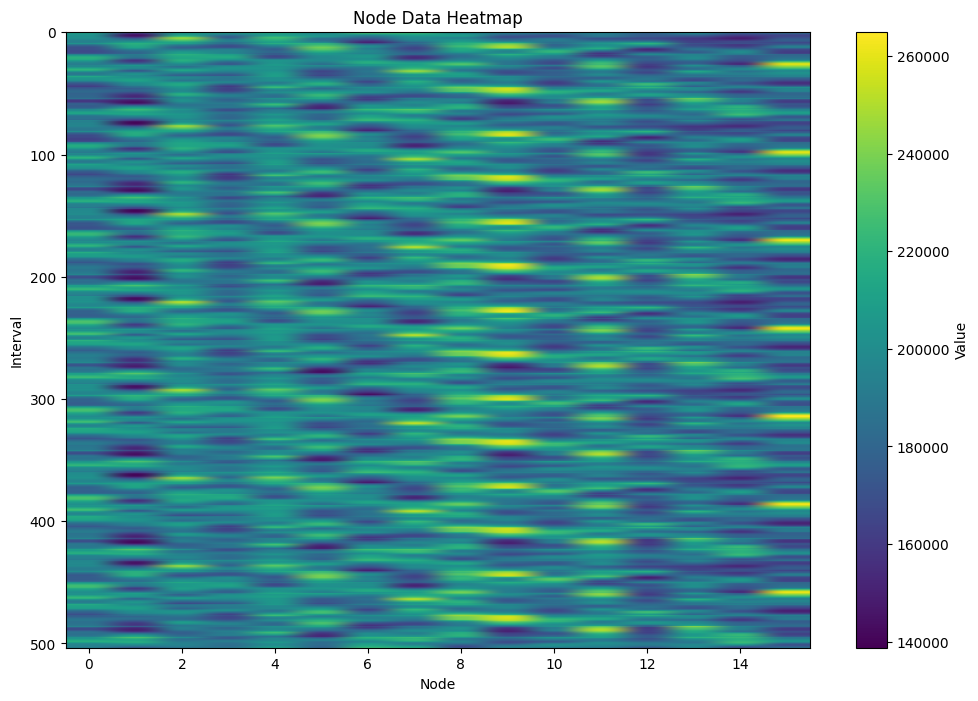

In [126]:
plot_simulation_heatmap(dynamic_summed_df, heatmap_type="node", path=f"test/plots/{test_name}")